<a href="https://colab.research.google.com/github/jfdmd/Deep-learning/blob/main/hw2_programming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 1
## Dataset Generation

Write a function to **generate a training set** of size $m$
- randomly generate a weight vector $w \in \mathbb{R}^{10}$, normalize length
- generate a training set $\{(x_i , y_i)\}$ of size m
  - $x_i$: random vector in $\mathbb{R}^{10}$ from $\textbf{N}(0, I)$
  - $y_i$: $\{0, +1\}$ with $P[y = +1] = \sigma(w \cdot x_i)$ and $P[y = 0] = 1 - \sigma(w \cdot x_i)$

In [81]:
def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-z))

def generate_data(m, d=10):
    """Generate a dataset using a true weight vector w* of dimension d.
    Returns (w_true, X, y) where:
      - w_true: numpy array shape (d,) with norm 1
      - X: numpy array shape (m, d) of standard normal samples
      - y: numpy array shape (m,) with values 0 or 1 sampled with P(y=1)=sigma(w*^T x)
    """


    w_star = np.random.randn(d)
    w_star = w_star / np.linalg.norm(w_star)
    X = np.random.randn(m, d)
    probs = _sigmoid(X.dot(w_star))
    y = (np.random.rand(m) < probs).astype(int)
    return w_star, X, y

## Algorithm 1: logistic regression

The goal is to learn $w$.  Algorithm 1 is logistic
  regression (you may use the built-in method LogisticRegression for this. Use max_iter=1000).

In [82]:

from sklearn.linear_model import LogisticRegression

def algorithm_1_logistic_regression(X, y):

    model = LogisticRegression(max_iter=1000, fit_intercept=False)
    model.fit(X, y)
    return model.coef_[0]

## Algorithm 2: gradient descent with square loss

Define square loss as
$$L_i(w^{(t)}) = \frac{1}{2} \left( \sigma(w^{(t)} \cdot x) - y_i \right)^2$$

  Algorithm 2 is
  gradient descent with respect to square loss (code this
  up yourself -- run for 1000 iterations, use step size eta = 0.01).

In [83]:


def gradient_square_loss(w, X, y):
    """Calculates the gradient of the average square loss.
    Args:
        w: current weight vector of shape (d,)
        X: array of shape (m, d)
        y: array of shape (m,) with binary labels
    Returns:
        Gradient vector of shape (d,).
    """
    m = X.shape[0]
    predictions = _sigmoid(X.dot(w))
    error = predictions - y
    sigmoid_prime = predictions * (1 - predictions) # Derivative of sigmoid
    gradient = (1.0 / m) * X.T.dot(error * sigmoid_prime)
    return gradient

def algorithm_2_gradient_descent(X, y, iterations=1000, eta=0.01):
    """Fits weights using gradient descent with square loss.
    Args:
        X: array of shape (m, d)
        y: array of shape (m,) with binary labels
        iterations: number of gradient descent iterations
        eta: learning rate
    Returns:
        w_hat: learned weight vector of shape (d,)
    """
    d = X.shape[1]
    w_prime_gd = np.zeros(d) # Initialize weights to zeros

    for i in range(iterations):
        grad = gradient_square_loss(w_prime_gd, X, y)
        w_prime_gd = w_prime_gd - eta * grad
    return w_prime_gd

## Algorithm 3: stochastic gradient descent with square loss
Similar to gradient descent, except we use the gradient at a single random training point every iteration.

In [84]:
def algorithm_3_sgd(X, y, iterations=1000, eta=0.01):
    """Fits weights using stochastic gradient descent with square loss.
    Args:
        X: array of shape (m, d)
        y: array of shape (m,) with binary labels
        iterations: number of gradient descent iterations
        eta: learning rate
    Returns:
        w_hat: learned weight vector of shape (d,)
    """
    d = X.shape[1]
    w_prime_sgd = np.zeros(d) # Initialize weights to zeros
    m = X.shape[0] # Number of samples for random selection

    for i_iter in range(iterations):
        # Randomly select one data point
        random_point = np.random.randint(0, m)
        X_sample = X[random_point:random_point+1] # Keep dimensions for dot product
        y_sample = y[random_point:random_point+1]

        grad = gradient_square_loss(w_prime_sgd, X_sample, y_sample)
        w_prime_sgd = w_prime_sgd - eta * grad
    return w_prime_sgd

## Evaluation

Measure error $\|w - \hat{w}\|_2$ for each method at different sample size. For any
  fixed value of $m$, choose many different $w$'s and average the
  values $\|w -
  \hat{w}\|_2$ for Algorithms 1, 2 and 3.  Plot the results
  for for each algorithm as you make $m$ large (use $m=50, 100, 150, 200, 250$).
  Also record, for each algorithm, the time taken to run the overall experiment.

In [85]:
import time

m_values = [50, 100, 150, 200, 250]
num_trials = 50 # Number of times to run each experiment for averaging

# To store results
errors_lr = []
errors_gd = []
errors_sgd = []
time_lr = []
time_gd = []
time_sgd = []

for m in m_values:
    print(f"Running experiments for m = {m}...")
    trial_errors_lr = []
    trial_errors_gd = []
    trial_errors_sgd = []

    start_time_m = time.time()

    for _ in range(num_trials):
        w_star, X, y = generate_data(m)

        # Algorithm 1: Logistic Regression
        start_lr = time.time()
        w_prime_lr = algorithm_1_logistic_regression(X, y)
        end_lr = time.time()
        trial_errors_lr.append(np.linalg.norm(w_star - w_prime_lr))
        time_lr.append(end_lr - start_lr)

        # Algorithm 2: Gradient Descent
        start_gd = time.time()
        w_hat_gd = algorithm_2_gradient_descent(X, y)
        end_gd = time.time()
        trial_errors_gd.append(np.linalg.norm(w_star - w_hat_gd))
        time_gd.append(end_gd - start_gd)

        # Algorithm 3: Stochastic Gradient Descent
        start_sgd = time.time()
        w_hat_sgd = algorithm_3_sgd(X, y)
        end_sgd = time.time()
        trial_errors_sgd.append(np.linalg.norm(w_star - w_hat_sgd))
        time_sgd.append(end_sgd - start_sgd)

    errors_lr.append(np.mean(trial_errors_lr))
    errors_gd.append(np.mean(trial_errors_gd))
    errors_sgd.append(np.mean(trial_errors_sgd))

    print(f"Finished experiments for m = {m}.")

Running experiments for m = 50...
Finished experiments for m = 50.
Running experiments for m = 100...
Finished experiments for m = 100.
Running experiments for m = 150...
Finished experiments for m = 150.
Running experiments for m = 200...
Finished experiments for m = 200.
Running experiments for m = 250...
Finished experiments for m = 250.


### Plotting Error vs. Sample Size (m)

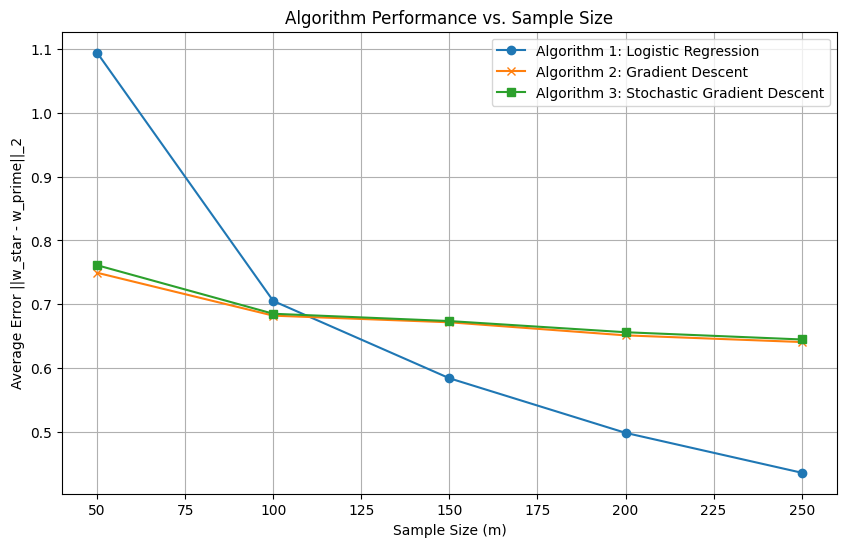

In [86]:
plt.figure(figsize=(10, 6))
plt.plot(m_values, errors_lr, label='Algorithm 1: Logistic Regression', marker='o')
plt.plot(m_values, errors_gd, label='Algorithm 2: Gradient Descent', marker='x')
plt.plot(m_values, errors_sgd, label='Algorithm 3: Stochastic Gradient Descent', marker='s')
plt.xlabel('Sample Size (m)')
plt.ylabel('Average Error ||w_star - w_prime||_2')
plt.title('Algorithm Performance vs. Sample Size')
plt.legend()
plt.grid(True)
plt.show()

### Plotting Time Taken vs. Sample Size (m)

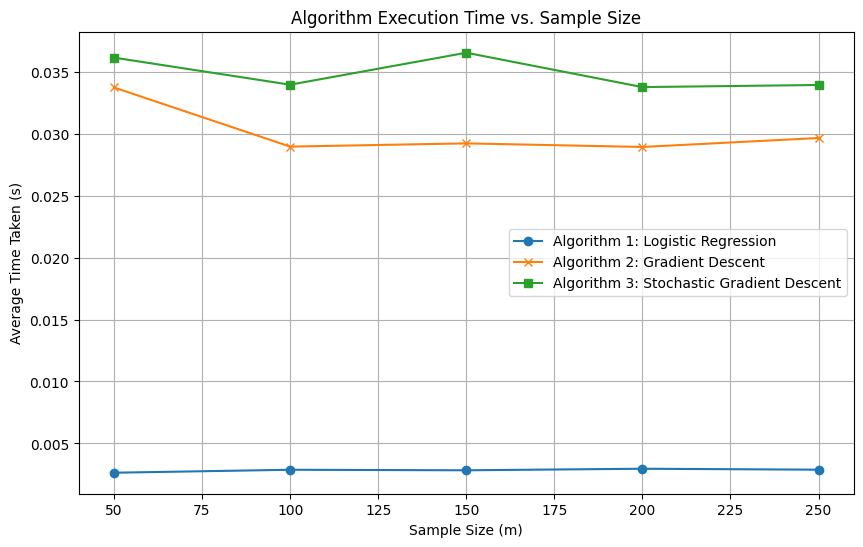

In [87]:
plt.figure(figsize=(10, 6))
plt.plot(m_values, time_lr[:len(m_values)], label='Algorithm 1: Logistic Regression', marker='o') # Only plot the first 'm_values' elements to correspond to m_values
plt.plot(m_values, time_gd[:len(m_values)], label='Algorithm 2: Gradient Descent', marker='x')
plt.plot(m_values, time_sgd[:len(m_values)], label='Algorithm 3: Stochastic Gradient Descent', marker='s')
plt.xlabel('Sample Size (m)')
plt.ylabel('Average Time Taken (s)')
plt.title('Algorithm Execution Time vs. Sample Size')
plt.legend()
plt.grid(True)
plt.show()

# Problem 2

In [88]:
from sklearn import datasets

In [89]:
cancer = datasets.load_breast_cancer()

For each depth in $1, \dots, 5$, instantiate an AdaBoost classifier with the base learner set to be a decision tree of that depth (set `n_estimators=10` and `learning_rate=1`), and then record the 10-fold cross-validated error on the entire breast cancer data set. Plot the resulting curve of accuracy against base classifier depth. Use $101$ as your random state for both the base learner as well as the AdaBoost classifier every time.

In [90]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# Prepare the data
X_cancer = cancer.data
y_cancer = cancer.target

depths = range(1, 6) # Depths from 1 to 5
accuracies = []

for depth in depths:
    # Define the base learner (Decision Tree Classifier)
    base_estimator = DecisionTreeClassifier(max_depth=depth, random_state=101)

    # Define the AdaBoost Classifier
    adaboost_model = AdaBoostClassifier(
        estimator= base_estimator,
        n_estimators=10,
        learning_rate=1,
        random_state=101
    )

    # Perform 10-fold cross-validation
    scores = cross_val_score(adaboost_model, X_cancer, y_cancer, cv=10, scoring='accuracy')
    mean_accuracy = np.mean(scores)
    accuracies.append(mean_accuracy)
    print(f"Depth: {depth}, Mean Accuracy: {mean_accuracy:.4f}")

Depth: 1, Mean Accuracy: 0.9508
Depth: 2, Mean Accuracy: 0.9508
Depth: 3, Mean Accuracy: 0.9648
Depth: 4, Mean Accuracy: 0.9579
Depth: 5, Mean Accuracy: 0.9666


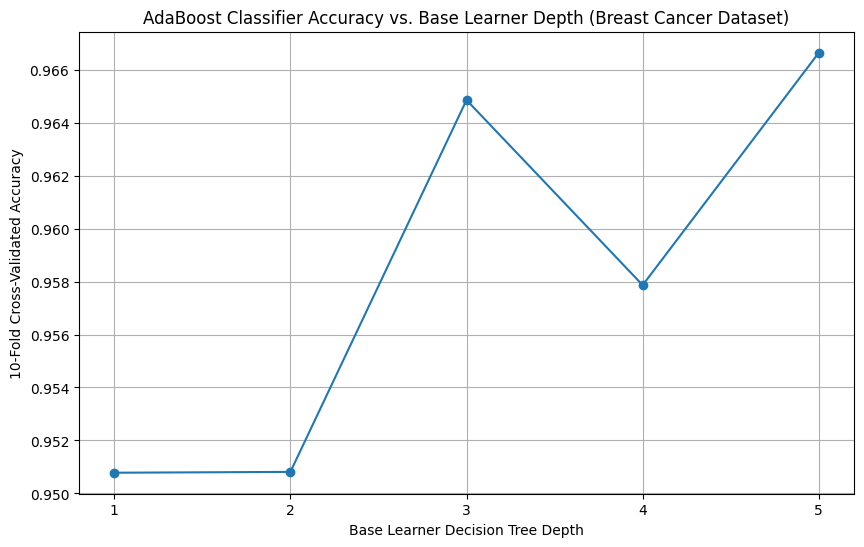

In [91]:
plt.figure(figsize=(10, 6))
plt.plot(depths, accuracies, marker='o', linestyle='-')
plt.title('AdaBoost Classifier Accuracy vs. Base Learner Depth (Breast Cancer Dataset)')
plt.xlabel('Base Learner Decision Tree Depth')
plt.ylabel('10-Fold Cross-Validated Accuracy')
plt.xticks(depths)
plt.grid(True)
plt.show()